# Clean spectra store — parameter histograms & snap diagnostics

Verifies a snap-filtered (`--filter-bad-snaps`) merged spectra store:

1. **Histograms of every parameter column** — requested/synthesis labels and the recorded MARCS atmosphere labels.
2. **Snap fidelity** — requested vs recorded MARCS values per axis, with the correlation signatures that exposed the original snapping bugs (old dataset: r(logg, marcs_logg) = 0.82, r(feh, marcs_fe_h) = 0.65, r(vmicro, marcs_fe_h) = 0.48).
3. **Correlation heatmap** of requested x MARCS columns (the upper-right quadrant of the full pair plot).
4. Optional **pair grid** over the key columns.

A healthy clean store shows: r ~ 1.00 on the requested-vs-marcs diagonal, r(vmicro, marcs_fe_h) ~ 0, `marcs_logg` extending below 3.0, and snap errors bounded by half the local MARCS grid spacing.

In [1]:
import os

# Point this at the clean store (the merge_spectra_runs.py --filter-bad-snaps output).
# Override without editing: CLEAN_ZARR=/path/to/store.zarr jupyter ...
_CANDIDATES = [
    os.environ.get("CLEAN_ZARR", ""),
    "/g/data/y89/mj8805/harps_final.zarr"
]
STORE_PATH = next(p for p in _CANDIDATES if p and os.path.exists(p))
MAKE_PAIR_GRID = True          # key-column pair grid (section 4)
PAIR_GRID_MAX_POINTS = 3000    # scatter subsample; histograms always use all rows
print(f"store: {STORE_PATH}")

store: /g/data/y89/mj8805/harps_final.zarr


In [2]:
import sys
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), "/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/scripts"))
from zarr_compat import open_root_group

root = open_root_group(STORE_PATH, mode="r")
param_names = [str(n) for n in root["param_names"][...]]
params = np.asarray(root["params"][...], dtype=np.float64)
cols = {name: params[:, i] for i, name in enumerate(param_names)}
n_rows = params.shape[0]

attrs = dict(root.attrs)
print(f"rows: {n_rows}, params: {len(param_names)}")
print(f"snap_filter_applied: {attrs.get('snap_filter_applied', '<not recorded>')}")
if "run_rows_kept" in attrs:
    print(f"run_rows_kept: {attrs['run_rows_kept']}  (of {attrs.get('run_rows', '?')})")
if "run_rows_wrong_snap" in attrs:
    print(f"run_rows_wrong_snap: {attrs['run_rows_wrong_snap']}")
print(f"columns: {param_names}")

rows: 206631, params: 21
snap_filter_applied: True
run_rows_kept: [132148, 74483]  (of [132148, 74483])
run_rows_wrong_snap: [0, 0]
columns: ['teff', 'logg', 'feh', 'vmicro', 'turbvel', 't_value', 'a', 'c', 'n', 'o', 'r', 's', 'mu', 'marcs_fe_h', 'marcs_a_fe', 'marcs_c_fe', 'marcs_n_fe', 'marcs_o_fe', 'marcs_teff', 'marcs_logg', 'marcs_turb']


In [3]:
# Chart style: validated reference palette (light mode), recessive chrome.
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
BLUE      = "#2a78d6"   # series 1 — the clean dataset
ORANGE    = "#eb6834"   # series 2 — the old (pre-fix) reference

# Sequential blue ramp (magnitude: hexbin density), surface -> deepest step.
SEQ = LinearSegmentedColormap.from_list("seq_blue", [
    SURFACE, "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b",
])
# Diverging blue <-> red with a neutral gray midpoint (correlation sign).
DIV = LinearSegmentedColormap.from_list("div_blue_red", [
    "#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f2a9a8", "#e34948", "#8c2b2a",
])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["system-ui", "-apple-system", "Segoe UI", "Helvetica Neue", "Arial", "sans-serif"],
    "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.titlecolor": INK, "axes.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
})

def tidy(ax):
    ax.grid(axis="x", visible=False)
    return ax

## 1. Parameter histograms — every column

Full-row histograms (no subsampling). Constant columns are labeled instead of plotted; all-NaN columns are skipped with a note.

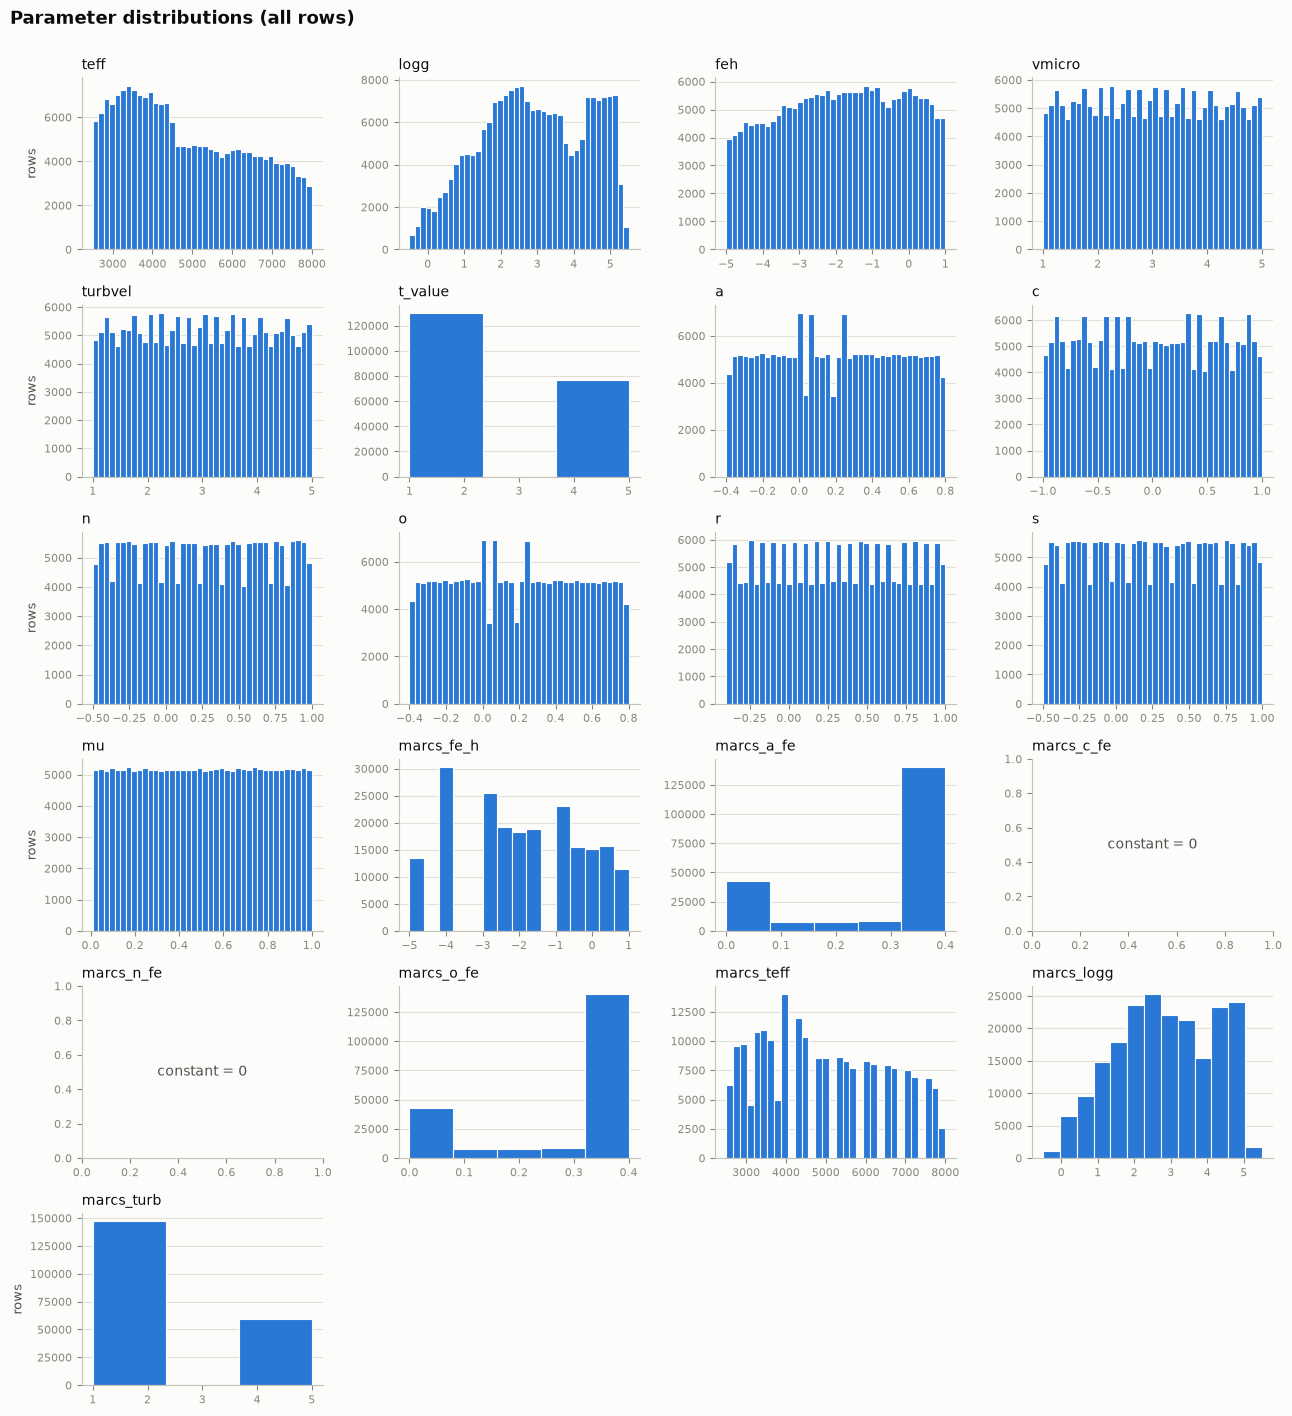

In [4]:
import math

# Patch font selection to avoid missing sans-serif warnings in Matplotlib
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

plot_names = list(param_names)
ncols = 4
nrows_grid = math.ceil(len(plot_names) / ncols)
fig, axes = plt.subplots(nrows_grid, ncols, figsize=(13, 2.4 * nrows_grid))
axes = np.atleast_2d(axes)

for k, name in enumerate(plot_names):
    ax = tidy(axes[k // ncols][k % ncols])
    values = cols[name]
    finite = values[~np.isnan(values)]
    n_nan = int(np.isnan(values).sum())
    title = name + (f"  ({n_nan} NaN)" if n_nan else "")
    ax.set_title(title, loc="left")
    if finite.size == 0:
        ax.text(0.5, 0.5, "all NaN", transform=ax.transAxes, ha="center", va="center", color=MUTED)
        ax.grid(False)
        continue
    if np.ptp(finite) == 0:
        ax.text(0.5, 0.5, f"constant = {finite[0]:g}", transform=ax.transAxes,
                ha="center", va="center", color=INK_2)
        ax.grid(False)
        continue
    n_unique = len(np.unique(finite))
    bins = min(40, n_unique) if n_unique <= 40 else 40
    ax.hist(finite, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
    ax.set_ylabel("rows" if k % ncols == 0 else "")

for k in range(len(plot_names), nrows_grid * ncols):
    axes[k // ncols][k % ncols].set_visible(False)

fig.suptitle("Parameter distributions (all rows)", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

## 2. Snap fidelity — requested vs recorded MARCS atmosphere

Each panel is a density (hexbin) of requested value vs the atmosphere the row was actually synthesised with; the hairline is the identity. In a clean store every point sits within half a grid step of the line and r ~ 1. `vmicro -> marcs_turb` shows the t-label quantisation (0/1/2/5 km/s), which is expected — babsma applies the requested vmicro exactly via XIFIX.

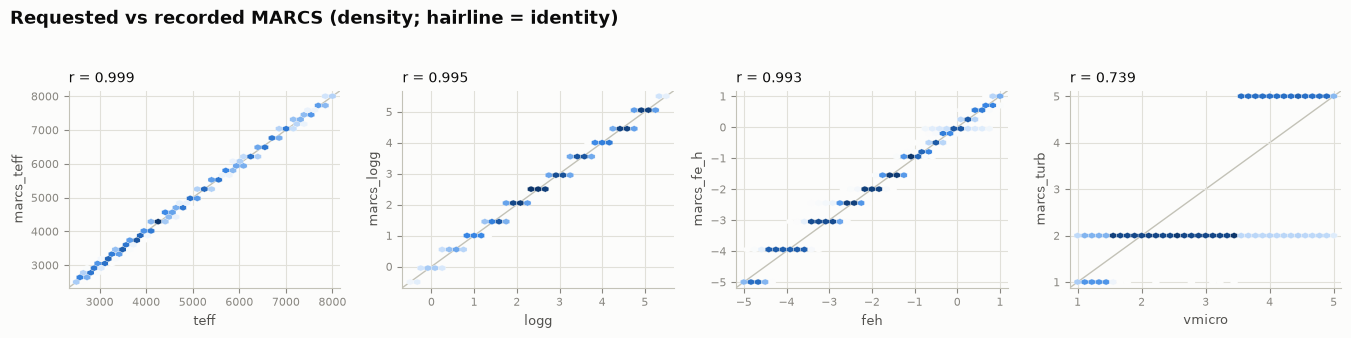

In [5]:
PAIRS = [
    ("teff", "marcs_teff"),
    ("logg", "marcs_logg"),
    ("feh", "marcs_fe_h"),
    ("vmicro", "marcs_turb"),
]
PAIRS = [(a, b) for a, b in PAIRS if a in cols and b in cols]

def pearson(x, y):
    ok = ~(np.isnan(x) | np.isnan(y))
    if ok.sum() < 2 or np.ptp(x[ok]) == 0 or np.ptp(y[ok]) == 0:
        return float("nan")
    return float(np.corrcoef(x[ok], y[ok])[0, 1])

fig, axes = plt.subplots(1, len(PAIRS), figsize=(3.4 * len(PAIRS), 3.4))
for ax, (req, rec) in zip(np.atleast_1d(axes), PAIRS):
    x, y = cols[req], cols[rec]
    ok = ~(np.isnan(x) | np.isnan(y))
    hb = ax.hexbin(x[ok], y[ok], gridsize=36, cmap=SEQ, mincnt=1, linewidths=0.2, edgecolors=SURFACE)
    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))
    pad = 0.03 * (hi - lo if hi > lo else 1)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=BASELINE, linewidth=1, zorder=0)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(req); ax.set_ylabel(rec)
    ax.set_title(f"r = {pearson(x, y):.3f}", loc="left")
fig.suptitle("Requested vs recorded MARCS (density; hairline = identity)",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

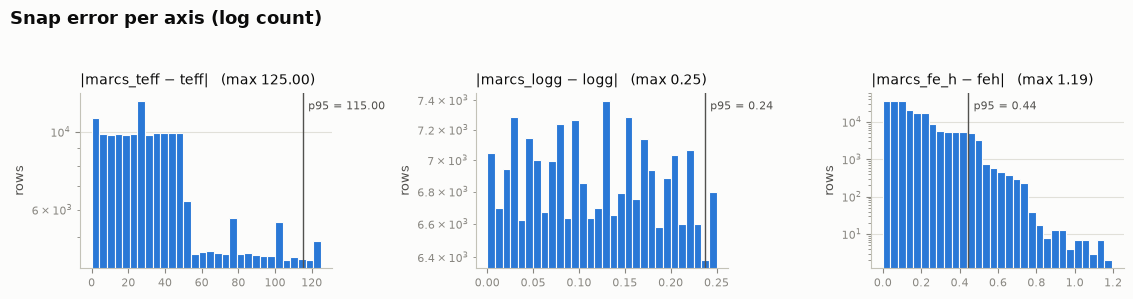

In [6]:
# Snap-error histograms: |recorded - requested| per axis.
ERR_PAIRS = [(a, b) for a, b in [("teff", "marcs_teff"), ("logg", "marcs_logg"), ("feh", "marcs_fe_h")]
             if a in cols and b in cols]
fig, axes = plt.subplots(1, len(ERR_PAIRS), figsize=(3.8 * len(ERR_PAIRS), 3.0))
for ax, (req, rec) in zip(np.atleast_1d(axes), ERR_PAIRS):
    tidy(ax)
    err = np.abs(cols[rec] - cols[req])
    err = err[~np.isnan(err)]
    ax.hist(err, bins=30, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
    p95 = np.percentile(err, 95)
    ax.axvline(p95, color=INK_2, linewidth=1)
    ax.annotate(f"p95 = {p95:.2f}", xy=(p95, 1), xycoords=("data", "axes fraction"),
                xytext=(4, -12), textcoords="offset points", color=INK_2, fontsize=8)
    ax.set_title(f"|{rec} − {req}|   (max {err.max():.2f})", loc="left")
    ax.set_ylabel("rows")
    ax.set_yscale("log")
fig.suptitle("Snap error per axis (log count)", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### Bug-signature correlations vs the old (pre-fix) dataset

The three correlations that exposed the snapping bugs, side by side with the values measured on the old harps pair plot. Targets: the first two ~ 1.0.

**Note on r(vmicro, marcs_fe_h):** in a store produced by *filtering* an old dataset, this can stay well above 0 without any wrong snaps — the filter removes metal-poor high-vmicro rows (the t05 trap) preferentially, so the surviving sample correlates vmicro with feh by construction. That is sampling bias in the kept rows, not snap error; the two r ~ 1 diagonals and the error histograms above are the correctness checks. In a dataset re-synthesised with the fixed snapper it should sit near 0.

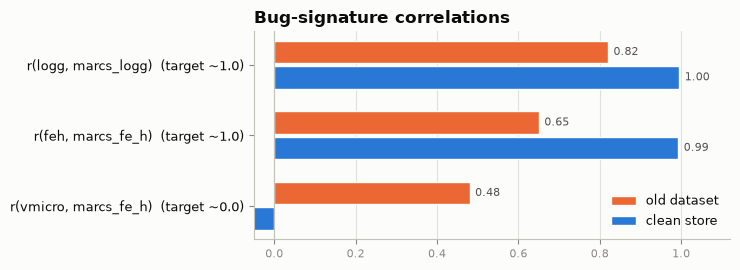

In [7]:
SIGNATURES = [
    ("r(logg, marcs_logg)",   pearson(cols.get("logg"), cols.get("marcs_logg")),   0.82, "~1.0"),
    ("r(feh, marcs_fe_h)",    pearson(cols.get("feh"), cols.get("marcs_fe_h")),    0.65, "~1.0"),
    ("r(vmicro, marcs_fe_h)", pearson(cols.get("vmicro"), cols.get("marcs_fe_h")), 0.48, "~0.0"),
]

fig, ax = plt.subplots(figsize=(7.5, 2.8))
tidy(ax)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ypos = np.arange(len(SIGNATURES))[::-1]
h = 0.32
old_vals = [s[2] for s in SIGNATURES]
new_vals = [s[1] for s in SIGNATURES]
ax.barh(ypos + h / 2 + 0.02, old_vals, height=h, color=ORANGE, edgecolor=SURFACE, linewidth=1, label="old dataset")
ax.barh(ypos - h / 2 - 0.02, new_vals, height=h, color=BLUE, edgecolor=SURFACE, linewidth=1, label="clean store")
for y0, (label, new, old, target) in zip(ypos, SIGNATURES):
    ax.annotate(f"{old:.2f}", xy=(old, y0 + h / 2 + 0.02), xytext=(4, 0),
                textcoords="offset points", va="center", color=INK_2, fontsize=8)
    ax.annotate(f"{new:.2f}", xy=(new, y0 - h / 2 - 0.02), xytext=(4, 0),
                textcoords="offset points", va="center", color=INK_2, fontsize=8)
ax.set_yticks(ypos, [f"{s[0]}  (target {s[3]})" for s in SIGNATURES])
ax.tick_params(axis="y", labelsize=9, labelcolor=INK)
ax.set_xlim(-0.05, 1.12)
ax.axvline(0, color=BASELINE, linewidth=0.8)
ax.legend(loc="lower right")
ax.set_title("Bug-signature correlations", loc="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Correlation heatmap — requested x MARCS columns

The upper-right quadrant of the full pair plot: Pearson r between each requested/synthesis label and each recorded MARCS label. Diverging blue (+) / red (−); constant columns are grayed out.

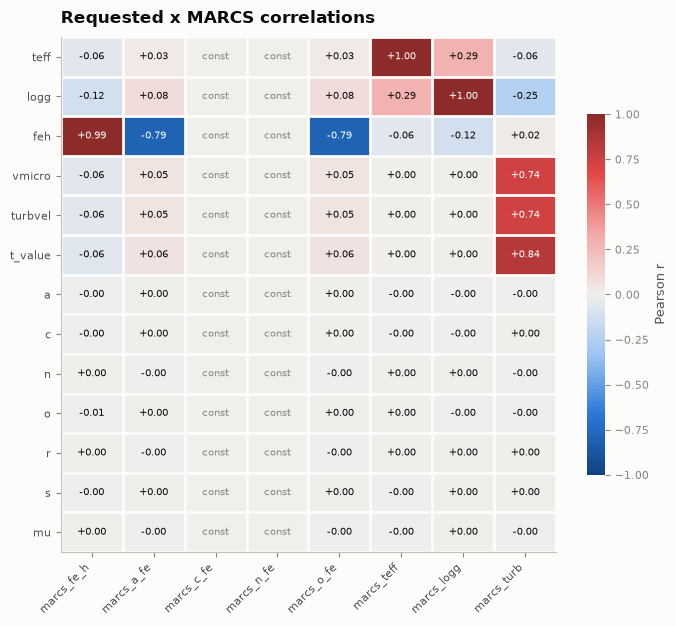

In [8]:
req_cols = [c for c in param_names if not c.startswith("marcs_")]
marcs_cols = [c for c in param_names if c.startswith("marcs_")]

R = np.full((len(req_cols), len(marcs_cols)), np.nan)
for i, a in enumerate(req_cols):
    for j, b in enumerate(marcs_cols):
        R[i, j] = pearson(cols[a], cols[b])

fig, ax = plt.subplots(figsize=(1.0 + 0.75 * len(marcs_cols), 0.9 + 0.42 * len(req_cols)))
ax.grid(False)
masked = np.ma.masked_invalid(R)
cmap = DIV.copy(); cmap.set_bad("#f0efec")
im = ax.imshow(masked, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(marcs_cols)), marcs_cols, rotation=45, ha="right", fontsize=8, color=INK_2)
ax.set_yticks(range(len(req_cols)), req_cols, fontsize=8, color=INK_2)
for i in range(len(req_cols)):
    for j in range(len(marcs_cols)):
        if np.isnan(R[i, j]):
            ax.text(j, i, "const", ha="center", va="center", fontsize=7, color=MUTED)
        else:
            dark_cell = abs(R[i, j]) > 0.6
            ax.text(j, i, f"{R[i, j]:+.2f}", ha="center", va="center", fontsize=7,
                    color=("#ffffff" if dark_cell else INK))
ax.set_xticks(np.arange(-0.5, len(marcs_cols)), minor=True)
ax.set_yticks(np.arange(-0.5, len(req_cols)), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)
cb = fig.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")
cb.outline.set_visible(False)
ax.set_title("Requested x MARCS correlations", loc="left", fontsize=12, fontweight="bold", pad=10)
fig.tight_layout()
plt.show()

## 4. Pair grid — key columns

Lower triangle: scatter on a subsample; diagonal: full-row histograms; upper triangle: Pearson r on all rows. Set `MAKE_PAIR_GRID = False` in the config cell to skip.

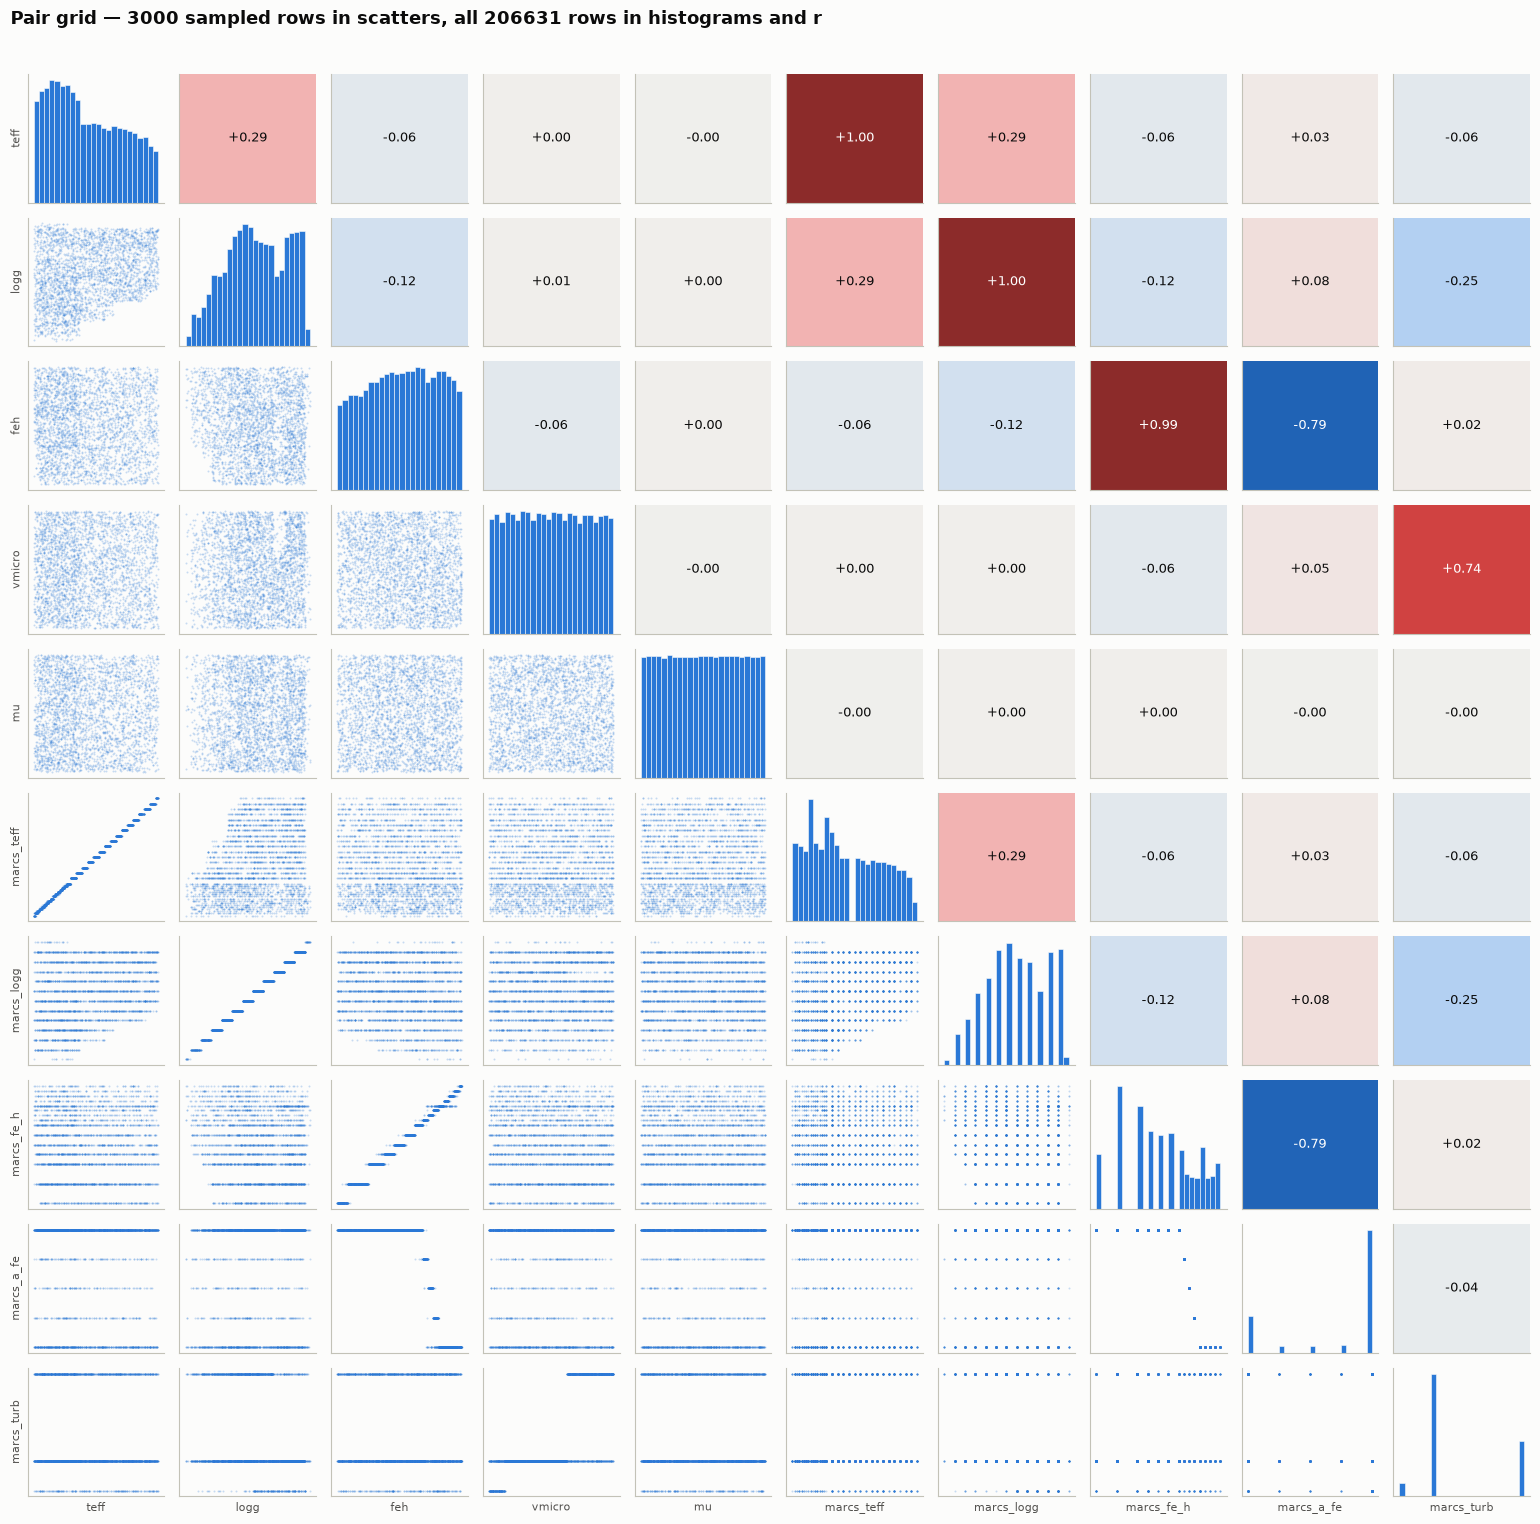

In [9]:
if MAKE_PAIR_GRID:
    key = [c for c in ("teff", "logg", "feh", "vmicro", "mu",
                       "marcs_teff", "marcs_logg", "marcs_fe_h", "marcs_a_fe", "marcs_turb")
           if c in cols]
    rng = np.random.default_rng(0)
    sub = rng.choice(n_rows, size=min(PAIR_GRID_MAX_POINTS, n_rows), replace=False)

    m = len(key)
    fig, axes = plt.subplots(m, m, figsize=(1.55 * m, 1.55 * m))
    for i, yname in enumerate(key):
        for j, xname in enumerate(key):
            ax = axes[i][j]
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            x, y = cols[xname], cols[yname]
            if i == j:
                finite = x[~np.isnan(x)]
                if finite.size and np.ptp(finite) > 0:
                    ax.hist(finite, bins=24, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
                else:
                    ax.text(0.5, 0.5, "const", transform=ax.transAxes,
                            ha="center", va="center", fontsize=7, color=MUTED)
            elif i > j:
                ax.scatter(x[sub], y[sub], s=2, color=BLUE, alpha=0.25, linewidths=0)
            else:
                r = pearson(x, y)
                if np.isnan(r):
                    ax.text(0.5, 0.5, "const", ha="center", va="center", fontsize=8, color=MUTED,
                            transform=ax.transAxes)
                else:
                    ax.set_facecolor(DIV((r + 1) / 2))
                    ax.text(0.5, 0.5, f"{r:+.2f}", ha="center", va="center", fontsize=9,
                            color=("#ffffff" if abs(r) > 0.6 else INK), transform=ax.transAxes)
            if i == m - 1:
                ax.set_xlabel(xname, fontsize=8, color=INK_2)
            if j == 0:
                ax.set_ylabel(yname, fontsize=8, color=INK_2)
    fig.suptitle(f"Pair grid — {min(PAIR_GRID_MAX_POINTS, n_rows)} sampled rows in scatters, "
                 f"all {n_rows} rows in histograms and r",
                 x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

## Checklist

A clean store should show, above:

- **Section 1**: `marcs_logg` extends below 3.0 (giants present, no pile-up at exactly 3.0); `marcs_fe_h` has no outsized spike at 0.0; `marcs_c_fe`/`marcs_n_fe` constant 0 (standard composition).
- **Section 2**: all requested-vs-marcs panels hug the identity line; teff/logg/feh r >= 0.96; snap errors bounded (teff <= 125 K, logg <= 0.25, feh <= ~0.5 dex except sparse low-metallicity cells).
- **Signatures**: r(logg, marcs_logg) and r(feh, marcs_fe_h) near 1. r(vmicro, marcs_fe_h) near 0 for re-synthesised data; for a filtered old dataset a residual correlation reflects which rows survived the filter (see note above), and the rejects summary tells you which parameter space to re-run to remove it.
- **Section 3**: the only strong off-diagonal structure is the physical alpha-[Fe/H] coupling (marcs_a_fe vs feh strongly negative) and marcs_o_fe = marcs_a_fe.

**Known failure signature:** `marcs_logg` piled up at exactly 3.0 while the requested `logg` histogram stays uniform below 3.0 (r ~ 0.82) means the filter ran against a **plane-parallel-only atmosphere pool** — with no spherical (`s*`) models the logg-3 clamp is the pool's true nearest, so clamped giants are structurally undetectable as wrong snaps. Check the pool with `ls <marcs_dir> | grep -c '^s'`; the filter also prints a WARNING with per-run `n_below_pool_logg_floor` counts. Remedy: re-filter with `--max-dlogg 0.25` (drops the clamped rows regardless of pool contents) and sync the spherical MARCS models before re-running the rejected parameter space.

If any signature is off, run `scripts/filter_bad_snap_rows.py -i <store> -a <marcs_dir>` — it reports wrong-snap rows directly.